# 训练曲线读图指南

本 notebook 用本工程 TinyViT 在 CIFAR-10 上的真实训练数据（`results/training_history.json`），教你系统地读懂训练曲线。所有图都从真实数据生成，重跑训练后图会自动更新。

## 分析训练数据的四步法

口诀：**看形状 → 找拐点 → 量鸿沟 → 看进度**

1. **看形状**：loss 该降的降、acc 该升的升、train 和 val 两条线是否"分叉"。分叉 = 过拟合信号。
2. **找拐点**：val_loss 最低的 epoch = 过拟合起点；val_acc 最高的 epoch = best。两拐点分离 = 过拟合标志。
3. **量鸿沟**：train vs val 的 acc gap（过拟合程度）、val vs test 的差距（泛化程度）。
4. **看进度**：lr 退火到哪了、epoch 占计划多少，判断"该不该继续训"。


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

# 中文字体（Windows 一般自带 SimHei / Microsoft YaHei）
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

# 加载本工程的训练历史
with Path('results/training_history.json').open(encoding='utf-8') as f:
    history = json.load(f)

epochs = [r['epoch'] for r in history]
train_loss = [r['train_loss'] for r in history]
val_loss = [r['validation_loss'] for r in history]
train_acc = [r['train_accuracy'] * 100 for r in history]
val_acc = [r['validation_accuracy'] * 100 for r in history]
lr_curve = [r['learning_rate'] for r in history]

# 两个关键拐点
best_idx = max(range(len(history)), key=lambda i: history[i]['validation_accuracy'])
min_vl_idx = min(range(len(history)), key=lambda i: history[i]['validation_loss'])
best = history[best_idx]
minvl = history[min_vl_idx]
last = history[-1]
ep_best = best['epoch']
ep_min_vl = minvl['epoch']

print('总 epoch 数：', len(history))
print('best val_acc @ ep%d = %.4f  (val_loss=%.4f)' % (ep_best, best['validation_accuracy'], best['validation_loss']))
print('min val_loss @ ep%d = %.4f  (val_acc=%.4f)  <- 过拟合起点' % (ep_min_vl, minvl['validation_loss'], minvl['validation_accuracy']))
print('两拐点分离：%d epoch（分离 = 过拟合铁证）' % (ep_best - ep_min_vl))
print('最后 ep%d：train_acc=%.1f%%  val_acc=%.1f%%  gap=%.1fpt' % (last['epoch'], last['train_accuracy']*100, last['validation_accuracy']*100, (last['train_accuracy']-last['validation_accuracy'])*100))


总 epoch 数： 163
best val_acc @ ep144 = 0.8292  (val_loss=0.7574)
min val_loss @ ep45 = 0.5970  (val_acc=0.8044)  <- 过拟合起点
两拐点分离：99 epoch（分离 = 过拟合铁证）
最后 ep163：train_acc=95.8%  val_acc=81.2%  gap=14.5pt


## 准备工作说明

上面的单元格做了三件事：

1. 设置中文字体，让图里的中文标注能正常显示。
2. 读取 `results/training_history.json`，把每个 epoch 的 6 个字段拆成列表。
3. 计算两个关键拐点：
   - `ep_best`：val_acc 最高的 epoch（对应 best checkpoint）
   - `ep_min_vl`：val_loss 最低的 epoch（过拟合起点）

后面四步分析都会用到这两个拐点。


## 第一步 看形状

先画出原始 loss 和 accuracy 曲线，**不加任何标注**，只看两件事：

- 曲线趋势对不对（loss 降、acc 升）
- **train 和 val 两条线是否分叉**：分叉说明模型开始"记住"训练集而不是"理解"，即过拟合的苗头

看 loss 子图：train 一直降，val 先降后升（U 形）—— val 反弹就是过拟合。
看 accuracy 子图：train 一路升到很高，val 升到平台后停 —— 平台之后的 gap 就是过拟合缺口。


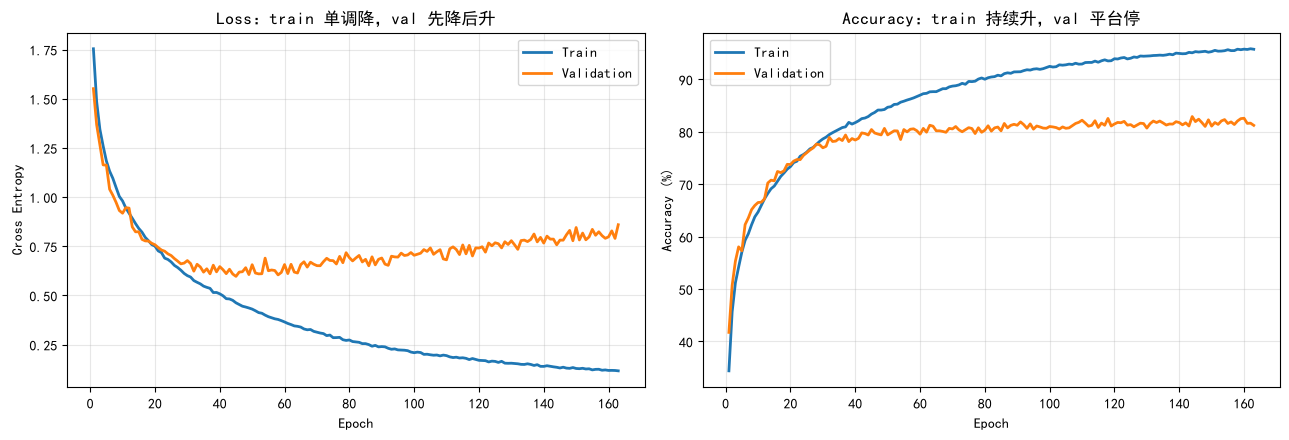

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epochs, train_loss, label='Train', lw=2)
axes[0].plot(epochs, val_loss, label='Validation', lw=2)
axes[0].set_title('Loss：train 单调降，val 先降后升')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross Entropy')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, train_acc, label='Train', lw=2)
axes[1].plot(epochs, val_acc, label='Validation', lw=2)
axes[1].set_title('Accuracy：train 持续升，val 平台停')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()


## 第二步 找拐点

在 loss 曲线上标两根竖虚线：

- **绿区 = 早期收敛**：模型还在学，train 和 val 都在改善
- **红区 = 过拟合反弹区**：val_loss 不降反升
- **ep_min_vl（val_loss 最低）**：过拟合起点，模型从这开始"记住"训练集
- **ep_best（val_acc 最高）**：best checkpoint 的位置

**关键观察**：这两个拐点常常不在同一处。两拐点分离 = 过拟合的铁证，也是"best 选 val_acc 最高 vs 选 val_loss 最低"会得到不同权重的根因。（具体数值见上面单元格的输出。）


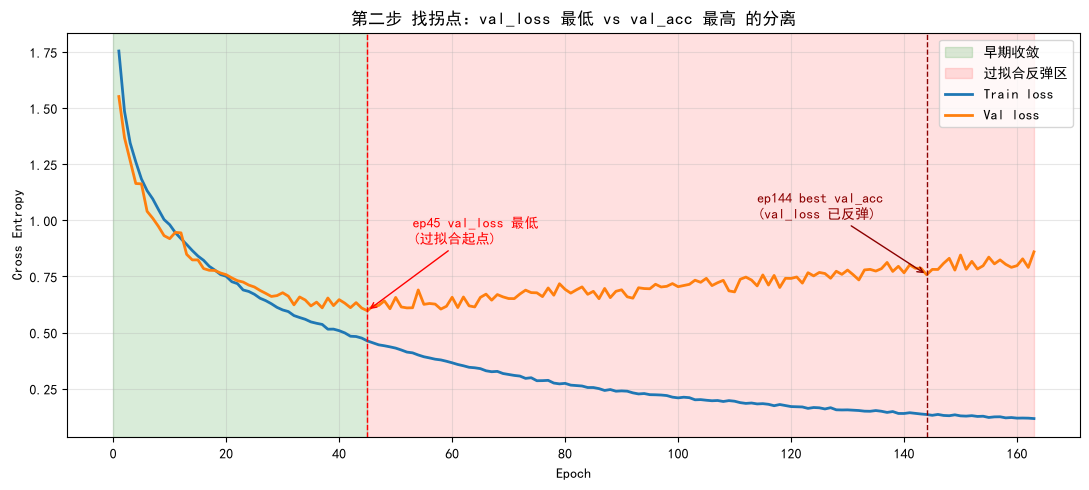

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(0, ep_min_vl, alpha=0.15, color='green', label='早期收敛')
ax.axvspan(ep_min_vl, epochs[-1], alpha=0.12, color='red', label='过拟合反弹区')
ax.plot(epochs, train_loss, label='Train loss', lw=2, color='tab:blue')
ax.plot(epochs, val_loss, label='Val loss', lw=2, color='tab:orange')
ax.axvline(ep_min_vl, color='red', ls='--', lw=1)
ax.axvline(ep_best, color='darkred', ls='--', lw=1)
ax.annotate('ep%d val_loss 最低\n(过拟合起点)' % ep_min_vl,
            xy=(ep_min_vl, minvl['validation_loss']),
            xytext=(ep_min_vl+8, minvl['validation_loss']+0.3),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate('ep%d best val_acc\n(val_loss 已反弹)' % ep_best,
            xy=(ep_best, best['validation_loss']),
            xytext=(ep_best-30, best['validation_loss']+0.25),
            fontsize=10, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))
ax.set_title('第二步 找拐点：val_loss 最低 vs val_acc 最高 的分离')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross Entropy')
ax.grid(alpha=0.3); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()


## 第三步 量鸿沟

在 accuracy 曲线上量两个 gap：

- **train/val gap**（末端两线间距）：过拟合程度，越大越严重
- **val vs test**：泛化程度，接近 = 泛化正常，差距大 = 选择偏差或分布不同

红色 × 是 test 点。它几乎贴在 val 曲线上 = best checkpoint 泛化没问题，过拟合还没伤到测试集。


In [ ]:
# 尝试读取 test 结果
test_acc = None
try:
    with Path('results/evaluation_summary.json').open(encoding='utf-8') as f:
        summary = json.load(f)
    test_acc = summary['test_accuracy'] * 100
except Exception:
    pass

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(0, 20, alpha=0.15, color='orange')           # 欠拟合
ax.axvspan(20, ep_min_vl, alpha=0.15, color='green')    # 最佳
ax.axvspan(ep_min_vl, epochs[-1], alpha=0.12, color='red')  # 过拟合
ax.plot(epochs, train_acc, label='Train acc', lw=2, color='tab:blue')
ax.plot(epochs, val_acc, label='Val acc', lw=2, color='tab:orange')

# train/val gap
gap = train_acc[-1] - val_acc[-1]
ax.annotate('', xy=(epochs[-1], train_acc[-1]), xytext=(epochs[-1], val_acc[-1]),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(epochs[-1]-4, (train_acc[-1]+val_acc[-1])/2, 'gap %.1fpt' % gap, fontsize=10, color='gray', ha='right')

# best val_acc 点
ax.scatter([ep_best], [best['validation_accuracy']*100], color='darkred', zorder=5)
ax.annotate('ep%d best val_acc\n%.1f%%' % (ep_best, best['validation_accuracy']*100),
            xy=(ep_best, best['validation_accuracy']*100),
            xytext=(ep_best-32, best['validation_accuracy']*100+8),
            fontsize=10, color='darkred', arrowprops=dict(arrowstyle='->', color='darkred'))

# test 点
if test_acc is not None:
    ax.scatter([ep_best], [test_acc], marker='x', color='red', s=90, zorder=5, label='test %.1f%%' % test_acc)
    ax.annotate('test %.1f%%' % test_acc, xy=(ep_best, test_acc),
                xytext=(ep_best+4, test_acc-7), fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('第三步 量鸿沟：train/val gap 与 test 点')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.grid(alpha=0.3); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


## 第四步 看进度

看学习率余弦退火曲线：lr 退到哪了？epoch 占计划多少？

**但注意**：进度低 ≠ 该续训。如果第二步已经确认过拟合，继续训只会让 val_loss 继续涨，test 不会变好。此时应该**就此分析**或**加正则/降 lr fine-tune**，而不是简单续训。


In [ ]:
NUM_EPOCHS_PLANNED = 500  # 见 config.py
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(epochs, lr_curve, color='tab:purple', lw=2)
ax.axvline(NUM_EPOCHS_PLANNED, color='gray', ls=':', lw=1)
ax.text(NUM_EPOCHS_PLANNED, max(lr_curve)*0.95, ' 计划 %d' % NUM_EPOCHS_PLANNED, fontsize=9, color='gray')
ax.axvline(epochs[-1], color='red', ls='--', lw=1)
ax.text(epochs[-1], max(lr_curve)*0.8, ' 实际 ep%d (%.0f%%)' % (epochs[-1], epochs[-1]/NUM_EPOCHS_PLANNED*100), fontsize=10, color='red')
ax.set_title('第四步 看进度：余弦退火到哪了')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('lr 从 %.2e 退到 %.2e（终点 1e-6，还差 %.0f 倍）' % (lr_curve[0], lr_curve[-1], lr_curve[-1]/1e-6))


## 综合：完整标注版

把四步的标注叠加到一张图上，就是可以直接放进学习笔记/博客的"成品训练曲线"。


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1 Loss
ax = axes[0]
ax.axvspan(0, ep_min_vl, alpha=0.15, color='green')
ax.axvspan(ep_min_vl, epochs[-1], alpha=0.12, color='red')
ax.plot(epochs, train_loss, label='Train', lw=2)
ax.plot(epochs, val_loss, label='Validation', lw=2)
ax.axvline(ep_min_vl, color='red', ls='--', lw=1)
ax.axvline(ep_best, color='darkred', ls='--', lw=1)
ax.set_title('Loss · 过拟合起点与 best 分离')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross Entropy')
ax.grid(alpha=0.3); ax.legend()

# 子图2 Accuracy
ax = axes[1]
ax.axvspan(0, 20, alpha=0.15, color='orange')
ax.axvspan(20, ep_min_vl, alpha=0.15, color='green')
ax.axvspan(ep_min_vl, epochs[-1], alpha=0.12, color='red')
ax.plot(epochs, train_acc, label='Train', lw=2)
ax.plot(epochs, val_acc, label='Validation', lw=2)
ax.axvline(ep_min_vl, color='red', ls='--', lw=1)
ax.axvline(ep_best, color='darkred', ls='--', lw=1)
ax.scatter([ep_best], [best['validation_accuracy']*100], color='darkred', zorder=5)
if test_acc is not None:
    ax.scatter([ep_best], [test_acc], marker='x', color='red', s=90, zorder=5)
ax.annotate('', xy=(epochs[-1], train_acc[-1]), xytext=(epochs[-1], val_acc[-1]),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(epochs[-1]-4, (train_acc[-1]+val_acc[-1])/2, 'gap %.1fpt' % gap, fontsize=9, color='gray', ha='right')
ax.set_title('Accuracy · 三阶段与 train/val 鸿沟')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.grid(alpha=0.3); ax.legend(loc='lower right')

# 子图3 LR
ax = axes[2]
ax.plot(epochs, lr_curve, color='tab:purple', lw=2)
ax.axvline(epochs[-1], color='red', ls='--', lw=1)
ax.text(epochs[-1], max(lr_curve)*0.85, ' ep%d/%d' % (epochs[-1], NUM_EPOCHS_PLANNED), fontsize=10, color='red')
ax.set_title('Learning Rate · 退火进度')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 小结

### 读图口诀
**看形状 → 找拐点 → 量鸿沟 → 看进度**

### 决策清单（套到本工程）

1. **形状**：train/val 分叉 → 过拟合已出现
2. **拐点**：val_loss 最低与 val_acc 最高分离 → 过拟合确认
3. **鸿沟**：train/val gap 大 = 过拟合程度；val/test 差小 = 泛化正常
4. **进度**：epoch 占计划比例 + lr 退火进度，但已过拟合则不续训

### 一句话

先看两条线分不分叉（形状），再找 val_loss 的拐点（过拟合起点），然后量 train/val 和 val/test 两个 gap，最后看 lr/epoch 进度判断该不该继续训。四步走完，训练状况一目了然。

### 附：混淆矩阵怎么读（你工程里已有 `confusion_matrix.png`）

- 该图已是**行归一化**（每行加起来 = 100%）
- **对角线** = 该类的召回率，越高越好
- **非对角线的亮格** = 误分到哪类：找到某一行（真实类），看那一行里除对角线外哪个格子最亮，就是"这个类最常被误判成什么"
- 把每行非对角最大那个挑出来 = **Top 误分类对**（典型如 cat↔dog、bird↔airplane）
